# Phase-Ramsey simulation with the BVA noise model

This notebook simulates

\[
rac{\pi}{2}(0) \;ightarrow\; 	ext{wait} \;ightarrow\;
rac{\pi}{2}(\phi) \;ightarrow\; 	ext{population measurement}
\]

for Ba-137 states with different measured magnetic-field sensitivities. Each
phase scan is fitted to a sine. The resulting normalized contrast is fitted to
the time-domain characteristic function of a Voigt frequency distribution,

\[
C(t)=C_0\exp\!\left[-(t/T_{2,G})^2-t/T_{2,L}ight],
\]

and the reported $T_2^*$ is the positive $1/e$ time of that fitted envelope.

The current scalar noise parameters are read directly from the BVA notebook at
run time. The stochastic distributions, Hamiltonian convention, calibration
lookups, and fitted AC-line model are imported from the same general simulation
helper used by the BVA analysis.

## 1. Imports and repository paths

In [1]:
from __future__ import annotations

import ast
import csv
import json
import sys
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import brentq, curve_fit

%matplotlib inline

SCRIPT_DIR = Path.cwd()
if not (SCRIPT_DIR / "phase_ramsey_simulation.py").exists():
    SCRIPT_DIR = Path(
        r"C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts"
        r"\Phase_Ramsey_simulation"
    )
REPO_ROOT = SCRIPT_DIR.parent
GENERAL_SIMULATION_DIR = REPO_ROOT / "General_Simulations"
if str(GENERAL_SIMULATION_DIR) not in sys.path:
    sys.path.insert(0, str(GENERAL_SIMULATION_DIR))

from sequence_simulation_helpers import (
    _line_model_arrays,
    build_transitions_list,
    compute_line_phase_corrections,
    compute_pi_time_matrix,
    default_line_noise_model,
    laser_noise_widths_hz,
    load_csv_matrix,
    sample_frequency_calibration_error_hz,
    sample_voigt_hz,
    simulate_schedule_state,
    values_from_matrix,
)

DEFAULT_BVA_NOTEBOOK = (
    REPO_ROOT / "BVA_analysis_scripts" / "BVA_qudit_analysis_script.ipynb"
)
DEFAULT_OUTPUT_DIR = SCRIPT_DIR / "results"

FALLBACK_SIMULATION_MAPPINGS = {
    0: "0",
    1: "[4, -2]",
    2: "[3, 1]",
    3: "[4, -1]",
    4: "[3, 0]",
    5: "[3, 2]",
    6: "[4, 0]",
    7: "[2, -2]",
    8: "[2, 0]",
    9: "[2, 2]",
    10: "[4, 1]",
    11: "[3, -1]",
    12: "[1, 1]",
    13: "[2, -1]",
    14: "[1, -1]",
    15: "[2, 1]",
}

REQUIRED_BVA_ASSIGNMENTS = (
    "simulation_mappings",
    "transition_strengths_file",
    "sensitivity_matrix_file",
    "line_signal_param_file",
    "reference_pi_times_us",
    "reference_strength_indices",
    "use_line_noise",
    "line_reference",
    "num_shots",
    "calibration_scale",
    "magnetic_scale",
    "laser_scale",
    "calibration_noise_hwhm_hz",
    "calibration_noise_sigma_hz",
    "magnetic_field_std_g",
    "laser_gaussian_T_s",
    "laser_lorentzian_L_s",
    "voigt_x_min_hz",
    "voigt_x_max_hz",
    "voigt_num_points",
    "rabi_frequency_std_fraction",
    "line_signal_noise_std_g",
    "paper_pi_time_scale",
)

## 2. Read the active BVA configuration

Only simple top-level assignments are parsed; the BVA notebook is **not**
executed here. This keeps the configuration traceable while avoiding accidental
execution of the full BVA analysis.

In [2]:
def _safe_assignment_value(node: ast.AST) -> Any:
    """Evaluate the small literal/arithmetic subset used by BVA configuration."""

    if isinstance(node, ast.Constant):
        return node.value
    if isinstance(node, ast.List):
        return [_safe_assignment_value(value) for value in node.elts]
    if isinstance(node, ast.Tuple):
        return tuple(_safe_assignment_value(value) for value in node.elts)
    if isinstance(node, ast.Dict):
        return {
            _safe_assignment_value(key): _safe_assignment_value(value)
            for key, value in zip(node.keys, node.values)
        }
    if isinstance(node, ast.UnaryOp):
        value = _safe_assignment_value(node.operand)
        if isinstance(node.op, ast.USub):
            return -value
        if isinstance(node.op, ast.UAdd):
            return +value
        raise ValueError(f"Unsupported unary operator: {ast.dump(node.op)}")
    if isinstance(node, ast.BinOp):
        left = _safe_assignment_value(node.left)
        right = _safe_assignment_value(node.right)
        if isinstance(node.op, ast.Add):
            return left + right
        if isinstance(node.op, ast.Sub):
            return left - right
        if isinstance(node.op, ast.Mult):
            return left * right
        if isinstance(node.op, ast.Div):
            return left / right
        if isinstance(node.op, ast.Pow):
            return left**right
        raise ValueError(f"Unsupported binary operator: {ast.dump(node.op)}")
    if (
        isinstance(node, ast.Attribute)
        and isinstance(node.value, ast.Name)
        and node.value.id == "np"
        and node.attr == "pi"
    ):
        return np.pi
    if (
        isinstance(node, ast.Call)
        and isinstance(node.func, ast.Attribute)
        and isinstance(node.func.value, ast.Name)
        and node.func.value.id == "np"
        and node.func.attr in {"array", "asarray"}
        and node.args
    ):
        return np.asarray(_safe_assignment_value(node.args[0]))
    raise ValueError(f"Unsupported configuration expression: {ast.dump(node)}")


def load_bva_configuration(notebook_path: Path) -> dict[str, Any]:
    """Read the latest top-level BVA configuration assignments without executing it."""

    with notebook_path.open("r", encoding="utf-8") as handle:
        notebook = json.load(handle)

    wanted = set(REQUIRED_BVA_ASSIGNMENTS)
    configuration: dict[str, Any] = {}
    for cell in notebook.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        source = "".join(cell.get("source", []))
        try:
            tree = ast.parse(source)
        except SyntaxError:
            continue
        for statement in tree.body:
            if not isinstance(statement, (ast.Assign, ast.AnnAssign)):
                continue
            targets = statement.targets if isinstance(statement, ast.Assign) else [statement.target]
            value_node = statement.value
            for target in targets:
                if not isinstance(target, ast.Name) or target.id not in wanted:
                    continue
                try:
                    configuration[target.id] = _safe_assignment_value(value_node)
                except (TypeError, ValueError):
                    pass

    if "simulation_mappings" not in configuration:
        configuration["simulation_mappings"] = FALLBACK_SIMULATION_MAPPINGS.copy()

    missing = sorted(wanted - configuration.keys())
    if missing:
        raise KeyError(
            "Could not recover these BVA settings from the notebook: "
            + ", ".join(missing)
        )
    return configuration


def resolve_bva_input_path(raw_path: str, fallback: Path) -> Path:
    """Use the active BVA path when mounted, otherwise use the repository copy."""

    candidate = Path(str(raw_path))
    try:
        candidate_exists = candidate.exists()
    except OSError:
        candidate_exists = False
    if candidate_exists:
        return candidate.resolve()
    if fallback.exists():
        return fallback.resolve()
    raise FileNotFoundError(
        f"Neither the BVA input path nor its local fallback exists: {candidate}, {fallback}"
    )


def resolve_calibration_inputs(configuration: dict[str, Any]) -> dict[str, Path]:
    return {
        "transition_strengths": resolve_bva_input_path(
            configuration["transition_strengths_file"],
            REPO_ROOT
            / "LineSignal_charaterization"
            / "Transition_strengths_4p209.txt",
        ),
        "sensitivities": resolve_bva_input_path(
            configuration["sensitivity_matrix_file"],
            REPO_ROOT
            / "Calibration_data_analysis"
            / "sensitivities_4p2079.txt",
        ),
        "line_signal": resolve_bva_input_path(
            configuration["line_signal_param_file"],
            REPO_ROOT
            / "LineSignal_charaterization"
            / "line_signal_fit_params_20260220.txt",
        ),
    }

## 3. Resolve calibrated transitions

Magnetic sensitivities and transition strengths come from the same matrices as
the BVA analysis. Compensated $\pi$ times retain the BVA timing scale.

In [3]:
def resolve_transition_properties(
    configuration: dict[str, Any], input_paths: dict[str, Path]
) -> list[dict[str, Any]]:
    mappings = {int(key): str(value) for key, value in configuration["simulation_mappings"].items()}
    state_indices = sorted(index for index in mappings if index != 0)
    couplings = [(0, state_index) for state_index in state_indices]
    transitions = build_transitions_list(mappings, couplings)

    sensitivity_matrix = load_csv_matrix(str(input_paths["sensitivities"]))
    sensitivities = values_from_matrix(transitions, sensitivity_matrix)

    transition_strengths = load_csv_matrix(str(input_paths["transition_strengths"]))
    pi_time_matrix = compute_pi_time_matrix(
        transition_strengths,
        np.asarray(configuration["reference_pi_times_us"], dtype=float),
        [tuple(indices) for indices in configuration["reference_strength_indices"]],
    )
    raw_pi_times_us = values_from_matrix(transitions, pi_time_matrix)
    pi_time_scale = float(configuration["paper_pi_time_scale"])

    return [
        {
            "state_index": int(state_index),
            "state_label": mappings[state_index],
            "coupling": (0, int(state_index)),
            "transition": list(transition),
            "sensitivity_mhz_per_g": float(sensitivity),
            "pi_time_us": float(raw_pi_time_us * pi_time_scale),
        }
        for state_index, transition, sensitivity, raw_pi_time_us in zip(
            state_indices, transitions, sensitivities, raw_pi_times_us
        )
    ]


def choose_representative_states(
    transitions: list[dict[str, Any]], count: int = 5
) -> list[int]:
    """Choose states spanning the measured absolute magnetic sensitivities."""

    ordered = sorted(
        transitions, key=lambda item: abs(item["sensitivity_mhz_per_g"])
    )
    count = min(max(int(count), 1), len(ordered))
    positions = np.rint(np.linspace(0, len(ordered) - 1, count)).astype(int)
    return [int(ordered[position]["state_index"]) for position in positions]

## 4. Two-level propagator and BVA noise draws

Calibration, magnetic, and laser detunings are quasi-static within a shot. The
same Rabi scale is shared by both Ramsey pulses. The deterministic fitted
AC-line signal and optional stochastic field offset follow the BVA timing
convention.

In [4]:
def apply_two_level_step(
    states: np.ndarray,
    duration_us: float,
    theta_rad: float,
    phase_rad: np.ndarray,
    detuning_mhz: np.ndarray,
    rabi_scale: np.ndarray,
) -> np.ndarray:
    """Apply the exact two-level propagator used by the BVA Hamiltonian convention."""

    states = np.asarray(states, dtype=complex)
    if duration_us <= 0.0:
        return states

    phase_rad = np.broadcast_to(np.asarray(phase_rad, dtype=float), states.shape[:1])
    detuning_mhz = np.broadcast_to(
        np.asarray(detuning_mhz, dtype=float), states.shape[:1]
    )
    rabi_scale = np.broadcast_to(np.asarray(rabi_scale, dtype=float), states.shape[:1])

    omega_rad_per_us = rabi_scale * float(theta_rad) / float(duration_us)
    detuning_rad_per_us = 2.0 * np.pi * detuning_mhz
    h00 = 0.5 * detuning_rad_per_us
    h01 = 0.5 * omega_rad_per_us * np.exp(1j * phase_rad)
    eigenfrequency = np.sqrt(h00**2 + (0.5 * omega_rad_per_us) ** 2)

    cosine = np.cos(eigenfrequency * duration_us)
    factor = np.empty_like(eigenfrequency, dtype=complex)
    nonzero = eigenfrequency > 0.0
    factor[nonzero] = (
        -1j
        * np.sin(eigenfrequency[nonzero] * duration_us)
        / eigenfrequency[nonzero]
    )
    factor[~nonzero] = -1j * duration_us

    state_0 = states[:, 0]
    state_1 = states[:, 1]
    output_0 = cosine * state_0 + factor * (h00 * state_0 + h01 * state_1)
    output_1 = cosine * state_1 + factor * (
        np.conjugate(h01) * state_0 - h00 * state_1
    )
    return np.column_stack((output_0, output_1))


def validate_two_level_propagator() -> None:
    """Check the vectorized propagator against the repository's BVA helper."""

    durations_us = np.asarray([12.0, 87.0, 12.0])
    thetas = np.asarray([np.pi / 2.0, 0.0, np.pi / 2.0])
    phases = np.asarray([0.17, 0.0, -0.73])
    global_detuning_mhz = 0.00019
    line_detunings_mhz = np.asarray([0.00003, -0.00002, 0.00001])
    line_phases_rad = np.asarray([0.02, -0.01, 0.04])
    rabi_scale = 1.037

    expected = simulate_schedule_state(
        couplings=[(0, 1)] * 3,
        durations_us=durations_us,
        thetas=thetas,
        programmed_phases=phases,
        initial_state=np.asarray([1.0, 0.0], dtype=complex),
        line_phase_offsets_rad=line_phases_rad,
        line_detunings_mhz=line_detunings_mhz,
        global_detuning_mhz_by_coupling={(0, 1): global_detuning_mhz},
        rabi_frequency_scales=np.full(3, rabi_scale),
    )

    actual = np.asarray([[1.0, 0.0]], dtype=complex)
    for step_index in range(3):
        actual = apply_two_level_step(
            actual,
            duration_us=float(durations_us[step_index]),
            theta_rad=float(thetas[step_index]),
            phase_rad=np.asarray([phases[step_index] + line_phases_rad[step_index]]),
            detuning_mhz=np.asarray(
                [global_detuning_mhz + line_detunings_mhz[step_index]]
            ),
            rabi_scale=np.asarray([rabi_scale]),
        )
    if not np.allclose(actual[0], expected, rtol=0.0, atol=2e-12):
        raise RuntimeError(
            "The vectorized Ramsey propagator does not match the BVA Hamiltonian helper"
        )


def line_reference_times_s(durations_us: np.ndarray, reference: str) -> np.ndarray:
    ends_us = np.cumsum(durations_us)
    starts_us = np.concatenate(([0.0], ends_us[:-1]))
    if reference == "start":
        return starts_us * 1e-6
    if reference == "end":
        return ends_us * 1e-6
    if reference == "mid":
        return 0.5 * (starts_us + ends_us) * 1e-6
    raise ValueError("line_reference must be 'start', 'mid', or 'end'")


def draw_bva_noise_trials(
    rng: np.random.Generator,
    trial_count: int,
    sensitivity_mhz_per_g: float,
    configuration: dict[str, Any],
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Draw the BVA quasi-static noise variables, vectorized over trials."""

    calibration_hz = float(configuration["calibration_scale"]) * (
        sample_frequency_calibration_error_hz(
            rng=rng,
            sigma_hz=float(configuration["calibration_noise_sigma_hz"]),
            hwhm_hz=float(configuration["calibration_noise_hwhm_hz"]),
            size=trial_count,
            x_min_hz=float(configuration["voigt_x_min_hz"]),
            x_max_hz=float(configuration["voigt_x_max_hz"]),
            num_points=int(configuration["voigt_num_points"]),
        )
    )

    magnetic_field_g = float(configuration["magnetic_scale"]) * rng.normal(
        0.0,
        float(configuration["magnetic_field_std_g"]),
        size=trial_count,
    )

    laser_sigma_hz, laser_gamma_hz = laser_noise_widths_hz(
        float(configuration["laser_gaussian_T_s"]),
        float(configuration["laser_lorentzian_L_s"]),
    )
    laser_hz = float(configuration["laser_scale"]) * sample_voigt_hz(
        rng=rng,
        sigma_hz=laser_sigma_hz,
        gamma_hz=laser_gamma_hz,
        size=trial_count,
        x_min_hz=float(configuration["voigt_x_min_hz"]),
        x_max_hz=float(configuration["voigt_x_max_hz"]),
        num_points=int(configuration["voigt_num_points"]),
    )

    detuning_mhz = (
        (calibration_hz + laser_hz) * 1e-6
        + magnetic_field_g * float(sensitivity_mhz_per_g)
    )
    rabi_scales = 1.0 + float(
        configuration["rabi_frequency_std_fraction"]
    ) * rng.normal(size=trial_count)
    line_offsets_g = float(configuration["line_signal_noise_std_g"]) * rng.normal(
        size=trial_count
    )
    return detuning_mhz, rabi_scales, line_offsets_g


def simulate_ramsey_phase_scan(
    phases_rad: np.ndarray,
    wait_time_us: float,
    transition: dict[str, Any],
    configuration: dict[str, Any],
    line_model: dict[str, Any],
    shots: int,
    rng: np.random.Generator,
    use_line_signal: bool,
) -> tuple[np.ndarray, np.ndarray]:
    """Return mean and shot-to-shot standard deviation at each scanned phase."""

    phase_count = len(phases_rad)
    trial_count = phase_count * int(shots)
    scan_phases = np.repeat(np.asarray(phases_rad, dtype=float), shots)
    sensitivity = float(transition["sensitivity_mhz_per_g"])
    half_pi_duration_us = 0.5 * float(transition["pi_time_us"])
    durations_us = np.asarray(
        [half_pi_duration_us, float(wait_time_us), half_pi_duration_us],
        dtype=float,
    )
    thetas = np.asarray([np.pi / 2.0, 0.0, np.pi / 2.0], dtype=float)

    base_line_phases, base_line_detunings, _ = compute_line_phase_corrections(
        durations_us,
        np.full(3, sensitivity, dtype=float),
        line_model=line_model,
        t_ref=str(configuration["line_reference"]),
        enabled=bool(use_line_signal),
    )
    detuning_mhz, rabi_scales, line_offsets_g = draw_bva_noise_trials(
        rng,
        trial_count,
        sensitivity,
        configuration,
    )

    reference_times_s = line_reference_times_s(
        durations_us, str(configuration["line_reference"])
    )
    line_offset_phases = (
        2.0
        * np.pi
        * 1e6
        * sensitivity
        * line_offsets_g[:, None]
        * reference_times_s[None, :]
    )
    line_offset_detunings = sensitivity * line_offsets_g[:, None]

    programmed_phases = np.column_stack(
        (
            np.zeros(trial_count),
            np.zeros(trial_count),
            scan_phases,
        )
    )
    total_phases = (
        programmed_phases
        + base_line_phases[None, :]
        + line_offset_phases
    )
    total_detunings = (
        detuning_mhz[:, None]
        + base_line_detunings[None, :]
        + line_offset_detunings
    )

    states = np.zeros((trial_count, 2), dtype=complex)
    states[:, 0] = 1.0
    for step_index in range(3):
        states = apply_two_level_step(
            states,
            duration_us=float(durations_us[step_index]),
            theta_rad=float(thetas[step_index]),
            phase_rad=total_phases[:, step_index],
            detuning_mhz=total_detunings[:, step_index],
            rabi_scale=rabi_scales,
        )

    excited_population = np.abs(states[:, 1]) ** 2
    populations_by_phase = excited_population.reshape(phase_count, shots)
    mean_population = np.mean(populations_by_phase, axis=1)
    population_std = (
        np.std(populations_by_phase, axis=1, ddof=1)
        if shots > 1
        else np.zeros(phase_count, dtype=float)
    )
    return mean_population, population_std

## 5. Fit each phase fringe

The population fringe is fitted to

\[
P(\phi)=B+A\sin(\phi+\phi_0).
\]

The normalized Ramsey contrast is $A/B$. Phase-point standard errors are used
as absolute fit uncertainties, and the linear-fit covariance is propagated to
$A$, $\phi_0$, and the contrast.

In [5]:
def fit_sine_fringe(
    phases_rad: np.ndarray,
    population: np.ndarray,
    population_sigma: np.ndarray | None = None,
) -> dict[str, float]:
    """Fit a sine fringe and propagate its linear-fit covariance.

    The fitted linear coefficients are converted to amplitude, phase, and the
    normalized contrast amplitude/offset. When supplied, population_sigma is
    treated as an absolute one-standard-deviation uncertainty on each mean.
    """

    phases_rad = np.asarray(phases_rad, dtype=float)
    population = np.asarray(population, dtype=float)
    design = np.column_stack(
        (np.ones_like(phases_rad), np.sin(phases_rad), np.cos(phases_rad))
    )

    use_weighted_fit = population_sigma is not None
    if use_weighted_fit:
        sigma = np.asarray(population_sigma, dtype=float)
        positive = sigma[np.isfinite(sigma) & (sigma > 0.0)]
        if positive.size == 0:
            use_weighted_fit = False
        else:
            sigma = sigma.copy()
            sigma[~np.isfinite(sigma) | (sigma <= 0.0)] = np.min(positive)

    if use_weighted_fit:
        weighted_design = design / sigma[:, None]
        weighted_population = population / sigma
        coefficients = np.linalg.lstsq(
            weighted_design, weighted_population, rcond=None
        )[0]
        coefficient_covariance = np.linalg.pinv(
            weighted_design.T @ weighted_design
        )
    else:
        coefficients = np.linalg.lstsq(design, population, rcond=None)[0]
        residual = population - design @ coefficients
        degrees_of_freedom = max(len(population) - design.shape[1], 1)
        residual_variance = float(residual @ residual) / degrees_of_freedom
        coefficient_covariance = residual_variance * np.linalg.pinv(
            design.T @ design
        )

    offset, sine_coefficient, cosine_coefficient = coefficients
    amplitude = float(np.hypot(sine_coefficient, cosine_coefficient))
    fitted_phase = float(np.arctan2(cosine_coefficient, sine_coefficient))
    fitted_population = offset + amplitude * np.sin(phases_rad + fitted_phase)
    residual_rms = float(np.sqrt(np.mean((population - fitted_population) ** 2)))
    contrast = float(amplitude / offset) if offset != 0.0 else np.nan

    offset_gradient = np.asarray([1.0, 0.0, 0.0])
    if amplitude > 0.0:
        amplitude_gradient = np.asarray(
            [0.0, sine_coefficient / amplitude, cosine_coefficient / amplitude]
        )
        phase_gradient = np.asarray(
            [0.0, -cosine_coefficient / amplitude**2, sine_coefficient / amplitude**2]
        )
    else:
        amplitude_gradient = np.zeros(3)
        phase_gradient = np.zeros(3)
    if offset != 0.0 and amplitude > 0.0:
        contrast_gradient = np.asarray(
            [
                -amplitude / offset**2,
                sine_coefficient / (amplitude * offset),
                cosine_coefficient / (amplitude * offset),
            ]
        )
    else:
        contrast_gradient = np.zeros(3)

    def propagated_error(gradient: np.ndarray) -> float:
        variance = float(gradient @ coefficient_covariance @ gradient)
        return float(np.sqrt(max(variance, 0.0)))

    return {
        "offset": float(offset),
        "offset_error": propagated_error(offset_gradient),
        "amplitude": amplitude,
        "amplitude_error": propagated_error(amplitude_gradient),
        "phase_rad": fitted_phase,
        "phase_error_rad": propagated_error(phase_gradient),
        "contrast": contrast,
        "contrast_error": propagated_error(contrast_gradient),
        "residual_rms": residual_rms,
    }

## 6. Fit the Voigt characteristic function and extract $T_2^*$

The Gaussian and Lorentzian time constants are fitted simultaneously. Their
covariance is propagated to the positive time at which $C(t)/C_0=1/e$, matching
the Ramsey analysis convention used elsewhere in the repository.

In [6]:
def voigt_characteristic_function(
    wait_time_us: np.ndarray | float,
    initial_contrast: float,
    t2_gaussian_us: float,
    t2_lorentzian_us: float,
) -> np.ndarray | float:
    """Time-domain characteristic function of a Voigt frequency profile."""

    wait_time_us = np.asarray(wait_time_us, dtype=float)
    return initial_contrast * np.exp(
        -(wait_time_us / t2_gaussian_us) ** 2
        - wait_time_us / t2_lorentzian_us
    )


def calculate_effective_t2_star_us(
    t2_gaussian_us: float, t2_lorentzian_us: float
) -> float:
    """Return the positive 1/e time of the combined Voigt envelope."""

    def equation(wait_time_us: float) -> float:
        return float(
            np.exp(
                -(wait_time_us / t2_gaussian_us) ** 2
                - wait_time_us / t2_lorentzian_us
            )
            - 1.0 / np.e
        )

    upper = max(float(t2_gaussian_us), float(t2_lorentzian_us), 1.0)
    while equation(upper) > 0.0:
        upper *= 2.0
    return float(brentq(equation, 0.0, upper))


def effective_t2_star_uncertainty_us(
    t2_gaussian_us: float,
    t2_lorentzian_us: float,
    effective_t2_us: float,
    covariance: np.ndarray,
) -> float:
    """Propagate the Gaussian/Lorentzian covariance to the 1/e time."""

    wait_time_us = float(effective_t2_us)
    derivative_time = (
        2.0 * wait_time_us / t2_gaussian_us**2 + 1.0 / t2_lorentzian_us
    )
    derivative_gaussian = (
        2.0 * wait_time_us**2 / t2_gaussian_us**3
    ) / derivative_time
    derivative_lorentzian = (
        wait_time_us / t2_lorentzian_us**2
    ) / derivative_time
    gradient = np.asarray([derivative_gaussian, derivative_lorentzian])
    parameter_covariance = np.asarray(covariance, dtype=float)[1:3, 1:3]
    variance = float(gradient @ parameter_covariance @ gradient)
    return float(np.sqrt(max(variance, 0.0)))


def fit_voigt_contrast_decay(
    state_fit_rows: list[dict[str, Any]],
) -> dict[str, Any]:
    """Fit one state's normalized contrasts to the Voigt characteristic function."""

    wait_times_us = np.asarray(
        [row["wait_time_us"] for row in state_fit_rows], dtype=float
    )
    contrasts = np.asarray([row["contrast"] for row in state_fit_rows], dtype=float)
    errors = np.asarray(
        [row["contrast_error"] for row in state_fit_rows], dtype=float
    )
    valid = (
        np.isfinite(wait_times_us)
        & np.isfinite(contrasts)
        & np.isfinite(errors)
        & (errors > 0.0)
    )
    wait_times_us = wait_times_us[valid]
    contrasts = contrasts[valid]
    errors = errors[valid]
    if len(wait_times_us) < 4 or len(np.unique(wait_times_us)) < 4:
        raise ValueError("At least four distinct wait times are required for a Voigt fit")

    time_scale_us = max(
        float(np.mean(wait_times_us)), float(np.ptp(wait_times_us)), 1.0
    )
    parameters, covariance = curve_fit(
        voigt_characteristic_function,
        wait_times_us,
        contrasts,
        p0=[min(float(np.max(contrasts)), 1.0), time_scale_us, time_scale_us],
        bounds=([0.0, 1e-12, 1e-12], [1.2, np.inf, np.inf]),
        sigma=errors,
        absolute_sigma=True,
        maxfev=50_000,
    )
    initial_contrast, t2_gaussian_us, t2_lorentzian_us = parameters
    parameter_errors = np.sqrt(np.maximum(np.diag(covariance), 0.0))
    effective_t2_us = calculate_effective_t2_star_us(
        t2_gaussian_us, t2_lorentzian_us
    )
    effective_t2_error_us = effective_t2_star_uncertainty_us(
        t2_gaussian_us,
        t2_lorentzian_us,
        effective_t2_us,
        covariance,
    )
    fitted_contrasts = voigt_characteristic_function(
        wait_times_us,
        initial_contrast,
        t2_gaussian_us,
        t2_lorentzian_us,
    )
    chi_squared = float(np.sum(((contrasts - fitted_contrasts) / errors) ** 2))
    degrees_of_freedom = max(len(wait_times_us) - 3, 1)
    first_row = state_fit_rows[0]
    return {
        "state_index": int(first_row["state_index"]),
        "state_label": str(first_row["state_label"]),
        "sensitivity_mhz_per_g": float(first_row["sensitivity_mhz_per_g"]),
        "initial_contrast": float(initial_contrast),
        "initial_contrast_error": float(parameter_errors[0]),
        "t2_gaussian_us": float(t2_gaussian_us),
        "t2_gaussian_error_us": float(parameter_errors[1]),
        "t2_lorentzian_us": float(t2_lorentzian_us),
        "t2_lorentzian_error_us": float(parameter_errors[2]),
        "t2_star_us": effective_t2_us,
        "t2_star_error_us": effective_t2_error_us,
        "chi_squared": chi_squared,
        "reduced_chi_squared": chi_squared / degrees_of_freedom,
    }

## 7. Output and plotting helpers

In [7]:
def write_csv(path: Path, rows: list[dict[str, Any]]) -> None:
    if not rows:
        raise ValueError(f"No rows supplied for {path}")
    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)


def json_ready(value: Any) -> Any:
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, dict):
        return {str(key): json_ready(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(item) for item in value]
    return value


def plot_contrast(
    fit_rows: list[dict[str, Any]],
    decay_fit_rows: list[dict[str, Any]],
    output_dir: Path,
    show: bool = False,
) -> tuple[Path, Path]:
    figure, axis = plt.subplots(figsize=(7.2, 4.6), constrained_layout=True)
    state_indices = list(dict.fromkeys(int(row["state_index"]) for row in fit_rows))
    decay_lookup = {
        int(row["state_index"]): row for row in decay_fit_rows
    }
    for curve_index, state_index in enumerate(state_indices):
        rows = [row for row in fit_rows if int(row["state_index"]) == state_index]
        rows = sorted(rows, key=lambda row: float(row["wait_time_us"]))
        sensitivity = float(rows[0]["sensitivity_mhz_per_g"])
        decay = decay_lookup[state_index]
        label = (
            f"|0> <-> {rows[0]['state_label']}  "
            f"({sensitivity:+.3f} MHz/G, "
            f"T2*={decay['t2_star_us'] * 1e-3:.2f} ms)"
        )
        color = f"C{curve_index % 10}"
        wait_times_us = np.asarray(
            [row["wait_time_us"] for row in rows], dtype=float
        )
        axis.errorbar(
            wait_times_us * 1e-3,
            [row["contrast"] for row in rows],
            yerr=[row["contrast_error"] for row in rows],
            fmt="o",
            markersize=3.8,
            capsize=2.0,
            elinewidth=0.7,
            color=color,
        )
        dense_wait_times_us = np.linspace(
            float(np.min(wait_times_us)), float(np.max(wait_times_us)), 800
        )
        axis.plot(
            dense_wait_times_us * 1e-3,
            voigt_characteristic_function(
                dense_wait_times_us,
                decay["initial_contrast"],
                decay["t2_gaussian_us"],
                decay["t2_lorentzian_us"],
            ),
            linewidth=1.5,
            color=color,
            label=label,
        )

    axis.set_xlabel("Ramsey wait time (ms)")
    axis.set_ylabel("Ramsey contrast")
    axis.set_title("Phase-Ramsey Voigt characteristic-function fits")
    axis.set_xlim(left=0.0)
    maximum_contrast = max(float(row["contrast"]) for row in fit_rows)
    axis.set_ylim(0.0, max(1.02, 1.06 * maximum_contrast))
    axis.grid(True, alpha=0.25, linewidth=0.6)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.legend(frameon=False, fontsize=8)

    png_path = output_dir / "phase_ramsey_contrast.png"
    pdf_path = output_dir / "phase_ramsey_contrast.pdf"
    figure.savefig(png_path, dpi=300, bbox_inches="tight")
    figure.savefig(pdf_path, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(figure)
    return png_path, pdf_path

## 8. User controls

`STATE_INDICES = None` automatically chooses five states spanning the measured
absolute magnetic sensitivities. Replace it with a list such as
`[8, 6, 2, 7, 1]` to choose transitions explicitly.

The phase count must be at least 10, and the maximum wait is intentionally
limited to 2 ms.

In [8]:
BVA_NOTEBOOK = DEFAULT_BVA_NOTEBOOK
OUTPUT_DIR = DEFAULT_OUTPUT_DIR

STATE_INDICES = None
NUM_REPRESENTATIVE_STATES = 5
NUM_PHASES = 16
NUM_WAIT_TIMES = 17
MAX_WAIT_US = 2000.0
SHOTS_PER_PHASE = None  # None uses the current BVA num_shots value.
RNG_SEED = 137
DISABLE_DETERMINISTIC_LINE_SIGNAL = False
SAVE_OUTPUTS = True

if NUM_PHASES < 10:
    raise ValueError("NUM_PHASES must be at least 10")
if NUM_WAIT_TIMES < 2:
    raise ValueError("NUM_WAIT_TIMES must be at least 2")
if MAX_WAIT_US <= 0.0 or MAX_WAIT_US > 2000.0:
    raise ValueError("MAX_WAIT_US must be greater than 0 and no more than 2000")


## 9. Load the current BVA values and select transitions

In [9]:
validate_two_level_propagator()

notebook_path = Path(BVA_NOTEBOOK).resolve()
configuration = load_bva_configuration(notebook_path)
input_paths = resolve_calibration_inputs(configuration)
all_transitions = resolve_transition_properties(configuration, input_paths)
transition_lookup = {
    int(transition["state_index"]): transition
    for transition in all_transitions
}

selected_state_indices = (
    choose_representative_states(
        all_transitions,
        count=NUM_REPRESENTATIVE_STATES,
    )
    if STATE_INDICES is None
    else [int(index) for index in STATE_INDICES]
)
unknown_states = sorted(set(selected_state_indices) - transition_lookup.keys())
if unknown_states:
    raise ValueError(f"Unknown BVA state indices: {unknown_states}")
selected_transitions = [
    transition_lookup[index] for index in selected_state_indices
]

shots = int(
    configuration["num_shots"]
    if SHOTS_PER_PHASE is None
    else SHOTS_PER_PHASE
)
phases_rad = np.linspace(0.0, 2.0 * np.pi, NUM_PHASES, endpoint=False)
wait_times_us = np.linspace(0.0, MAX_WAIT_US, NUM_WAIT_TIMES)
use_line_signal = (
    bool(configuration["use_line_noise"])
    and not DISABLE_DETERMINISTIC_LINE_SIGNAL
)
line_model = default_line_noise_model(param_file=input_paths["line_signal"])

pd.DataFrame(selected_transitions)[
    [
        "state_index",
        "state_label",
        "sensitivity_mhz_per_g",
        "pi_time_us",
    ]
]


,state_index,state_label,sensitivity_mhz_per_g,pi_time_us
0,8,"[2, 0]",0.000041,79.040000
1,6,"[4, 0]",-1.386869,46.555038
2,2,"[3, 1]",2.138519,25.951404
3,7,"[2, -2]",-2.876890,56.401921
4,1,"[4, -2]",-3.420181,19.120000


## 10. Simulate all phase scans and fit their sine fringes

The raw table contains one row per state, wait time, and scanned phase. The
fringe-fit table contains the extracted amplitude, phase, normalized contrast,
and propagated uncertainties for every wait time.

In [10]:
rng = np.random.default_rng(RNG_SEED)
scan_rows = []
fit_rows = []

for transition in selected_transitions:
    print(
        f"Simulating state {transition['state_index']} "
        f"{transition['state_label']} at "
        f"{transition['sensitivity_mhz_per_g']:+.6g} MHz/G"
    )
    for wait_time_us in wait_times_us:
        mean_population, population_std = simulate_ramsey_phase_scan(
            phases_rad=phases_rad,
            wait_time_us=float(wait_time_us),
            transition=transition,
            configuration=configuration,
            line_model=line_model,
            shots=shots,
            rng=rng,
            use_line_signal=use_line_signal,
        )
        population_sem = population_std / np.sqrt(shots)
        fit = fit_sine_fringe(
            phases_rad,
            mean_population,
            population_sigma=population_sem,
        )
        fit_rows.append(
            {
                "state_index": transition["state_index"],
                "state_label": transition["state_label"],
                "sensitivity_mhz_per_g": transition[
                    "sensitivity_mhz_per_g"
                ],
                "pi_time_us": transition["pi_time_us"],
                "wait_time_us": float(wait_time_us),
                **fit,
            }
        )
        for phase_rad, mean_value, std_value in zip(
            phases_rad, mean_population, population_std
        ):
            fitted_value = fit["offset"] + fit["amplitude"] * np.sin(
                phase_rad + fit["phase_rad"]
            )
            scan_rows.append(
                {
                    "state_index": transition["state_index"],
                    "state_label": transition["state_label"],
                    "sensitivity_mhz_per_g": transition[
                        "sensitivity_mhz_per_g"
                    ],
                    "pi_time_us": transition["pi_time_us"],
                    "wait_time_us": float(wait_time_us),
                    "scan_phase_rad": float(phase_rad),
                    "mean_excited_population": float(mean_value),
                    "population_std_across_noise_shots": float(std_value),
                    "population_sem": float(std_value / np.sqrt(shots)),
                    "fitted_population": float(fitted_value),
                }
            )

scan_dataframe = pd.DataFrame(scan_rows)
fit_dataframe = pd.DataFrame(fit_rows)
fit_dataframe.head()


Simulating state 8 [2, 0] at +4.05898e-05 MHz/G


Simulating state 6 [4, 0] at -1.38687 MHz/G


Simulating state 2 [3, 1] at +2.13852 MHz/G


Simulating state 7 [2, -2] at -2.87689 MHz/G


Simulating state 1 [4, -2] at -3.42018 MHz/G


,state_index,state_label,sensitivity_mhz_per_g,pi_time_us,wait_time_us,offset,offset_error,amplitude,amplitude_error,phase_rad,phase_error_rad,contrast,contrast_error,residual_rms
0,8,"[2, 0]",0.000041,79.04,0.0,0.497876,0.000223,0.496341,0.000234,1.568672,0.001312,0.996917,0.000467,0.001529
1,8,"[2, 0]",0.000041,79.04,125.0,0.497446,0.000869,0.487445,0.000947,1.568132,0.004458,0.979896,0.002581,0.005043
2,8,"[2, 0]",0.000041,79.04,250.0,0.495314,0.002160,0.459845,0.002664,1.572158,0.007999,0.928391,0.006448,0.008407
3,8,"[2, 0]",0.000041,79.04,375.0,0.496265,0.003056,0.428258,0.003898,1.566658,0.011355,0.862964,0.009225,0.010561
4,8,"[2, 0]",0.000041,79.04,500.0,0.502148,0.003698,0.391067,0.004870,1.565424,0.014501,0.778790,0.011559,0.010933


## 11. Fit the contrast envelopes and report $T_2^*$

In [11]:
decay_fit_rows = []
for state_index in selected_state_indices:
    state_rows = [
        row for row in fit_rows
        if int(row["state_index"]) == state_index
    ]
    decay_fit_rows.append(fit_voigt_contrast_decay(state_rows))

t2_star_dataframe = pd.DataFrame(decay_fit_rows)
t2_star_dataframe[
    [
        "state_index",
        "state_label",
        "sensitivity_mhz_per_g",
        "t2_gaussian_us",
        "t2_gaussian_error_us",
        "t2_lorentzian_us",
        "t2_lorentzian_error_us",
        "t2_star_us",
        "t2_star_error_us",
        "reduced_chi_squared",
    ]
]


,state_index,state_label,sensitivity_mhz_per_g,t2_gaussian_us,t2_gaussian_error_us,t2_lorentzian_us,t2_lorentzian_error_us,t2_star_us,t2_star_error_us,reduced_chi_squared
0,8,"[2, 0]",0.000041,1733.476879,36.811441,4352.091004,276.017695,1422.289933,12.913295,6.504037
1,6,"[4, 0]",-1.386869,1499.169570,25.602321,5481.274802,408.742640,1308.106023,11.189700,4.950011
2,2,"[3, 1]",2.138519,1355.830691,21.679168,6338.085333,573.021207,1218.545832,10.326276,6.194818
3,7,"[2, -2]",-2.876890,1238.422585,23.715920,4128.306199,333.893170,1066.522801,9.533658,2.952828
4,1,"[4, -2]",-3.420181,1065.806804,17.510112,6296.496240,753.484558,979.412751,8.776574,3.456672


## 12. Save tables and exact run metadata

In [12]:
raw_csv_path = OUTPUT_DIR / "phase_ramsey_scans.csv"
fit_csv_path = OUTPUT_DIR / "phase_ramsey_fits.csv"
t2_csv_path = OUTPUT_DIR / "phase_ramsey_t2_star.csv"
metadata_path = OUTPUT_DIR / "phase_ramsey_metadata.json"

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    write_csv(raw_csv_path, scan_rows)
    write_csv(fit_csv_path, fit_rows)
    write_csv(t2_csv_path, decay_fit_rows)

    line_B0_mG, line_frequencies_hz, line_amplitudes_mG, line_phases_rad = (
        _line_model_arrays(line_model)
    )
    metadata = {
        "generated_utc": datetime.now(timezone.utc).isoformat(),
        "source_bva_notebook": notebook_path,
        "input_paths": input_paths,
        "selected_transitions": selected_transitions,
        "phase_count": int(NUM_PHASES),
        "phases_rad": phases_rad,
        "wait_times_us": wait_times_us,
        "shots_per_phase": shots,
        "rng_seed": int(RNG_SEED),
        "use_deterministic_line_signal": use_line_signal,
        "fit_model": "P(phi) = offset + amplitude*sin(phi + phase_rad)",
        "contrast_definition": "amplitude / offset",
        "decay_fit_model": (
            "C(t) = initial_contrast * exp(-(t/T2_G)^2 - t/T2_L)"
        ),
        "t2_star_definition": "positive time where C(t)/C(0) = 1/e",
        "t2_star_results": decay_fit_rows,
        "noise_model": {
            key: configuration[key]
            for key in REQUIRED_BVA_ASSIGNMENTS
            if key not in {
                "simulation_mappings",
                "transition_strengths_file",
                "sensitivity_matrix_file",
                "line_signal_param_file",
                "reference_pi_times_us",
                "reference_strength_indices",
                "paper_pi_time_scale",
                "num_shots",
            }
        },
        "reference_pi_times_us": configuration["reference_pi_times_us"],
        "reference_strength_indices": configuration[
            "reference_strength_indices"
        ],
        "pi_time_scale": configuration["paper_pi_time_scale"],
        "resolved_line_model": {
            "B0_mG": line_B0_mG,
            "frequencies_hz": line_frequencies_hz,
            "amplitudes_mG": line_amplitudes_mG,
            "phases_rad": line_phases_rad,
        },
    }
    with metadata_path.open("w", encoding="utf-8") as handle:
        json.dump(json_ready(metadata), handle, indent=2)

    print(f"Saved phase scans: {raw_csv_path}")
    print(f"Saved sine fits: {fit_csv_path}")
    print(f"Saved Voigt T2* fits: {t2_csv_path}")
    print(f"Saved metadata: {metadata_path}")


Saved phase scans: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Phase_Ramsey_simulation\results\phase_ramsey_scans.csv
Saved sine fits: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Phase_Ramsey_simulation\results\phase_ramsey_fits.csv
Saved Voigt T2* fits: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Phase_Ramsey_simulation\results\phase_ramsey_t2_star.csv
Saved metadata: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Phase_Ramsey_simulation\results\phase_ramsey_metadata.json


## 13. Plot contrast data and Voigt characteristic-function fits

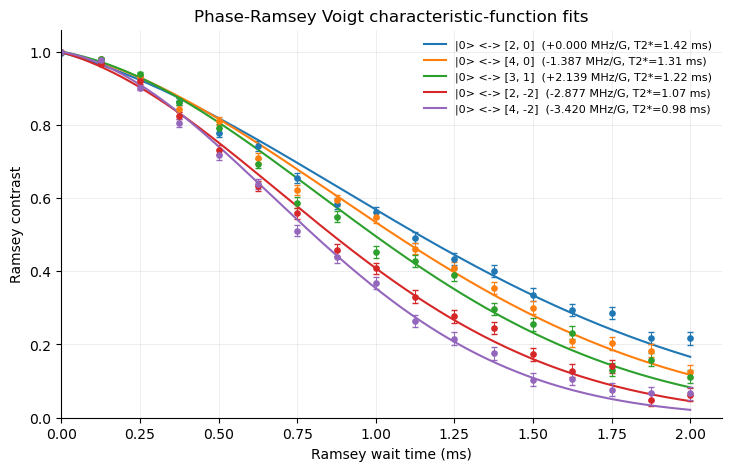

Saved contrast plot: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Phase_Ramsey_simulation\results\phase_ramsey_contrast.png
Saved contrast plot: C:\Users\iamga\OneDrive\Documents\GitHub\PhD_python_scripts\Phase_Ramsey_simulation\results\phase_ramsey_contrast.pdf


In [13]:
if SAVE_OUTPUTS:
    contrast_png_path, contrast_pdf_path = plot_contrast(
        fit_rows,
        decay_fit_rows,
        OUTPUT_DIR,
        show=True,
    )
    print(f"Saved contrast plot: {contrast_png_path}")
    print(f"Saved contrast plot: {contrast_pdf_path}")
else:
    temporary_output_dir = SCRIPT_DIR / "results"
    contrast_png_path, contrast_pdf_path = plot_contrast(
        fit_rows,
        decay_fit_rows,
        temporary_output_dir,
        show=True,
    )
